In [1]:
#Task 1: Exploring and Visualizing a Simple Dataset
#Step 1: Install and Import Libraries

In [43]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the built-in Iris dataset from seaborn
iris_df = sns.load_dataset('iris')
print("Dataset successfully loaded.")

Dataset successfully loaded.


In [24]:
#Step 2: Data Inspection
# 1. Print the shape of the dataset
print("Dataset Shape (Rows, Columns):", iris_df.shape)
print("-" * 50)

# 2. Print column names
print("Column Names:", iris_df.columns.tolist())
print("-" * 50)

# 3. Print the first few rows
print("First 5 rows of the dataset:")
print(iris_df.head())
print("-" * 50)

# 4. Dataset information (Data types and null values)
print("Dataset Summary Info:")
iris_df.info()
print("-" * 50)

# 5. Descriptive statistics
print("Summary Statistics:")
print(iris_df.describe())

Dataset Shape (Rows, Columns): (150, 5)
--------------------------------------------------
Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
--------------------------------------------------
First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
--------------------------------------------------
Dataset Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   pet

In [25]:
#Step 3: Data Visualization

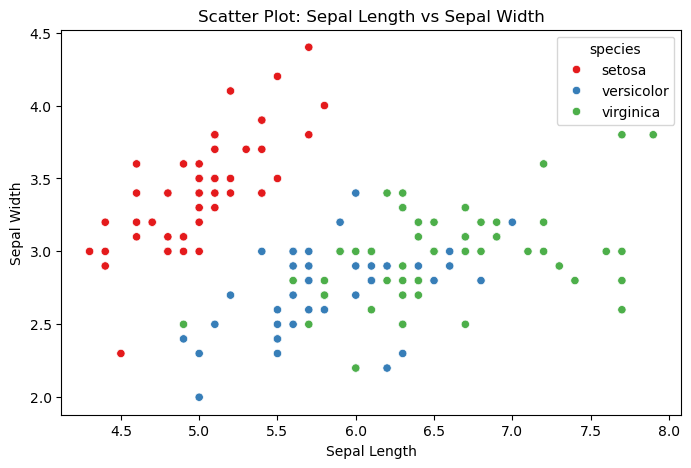

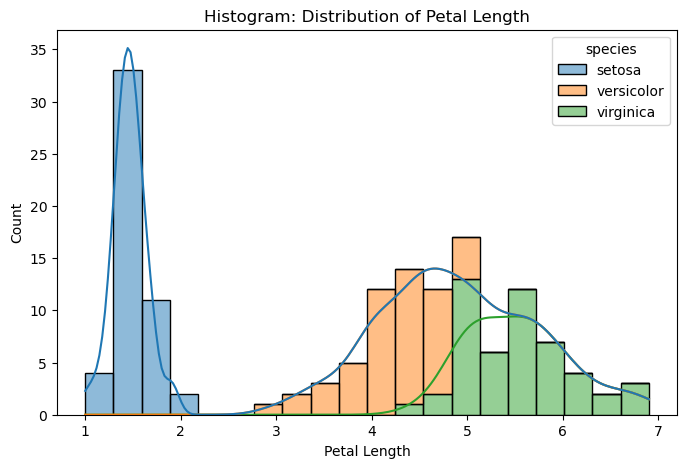

C:\Users\PMLS\AppData\Local\Temp\ipykernel_21432\638195976.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y='sepal_width', palette='Pastel1')


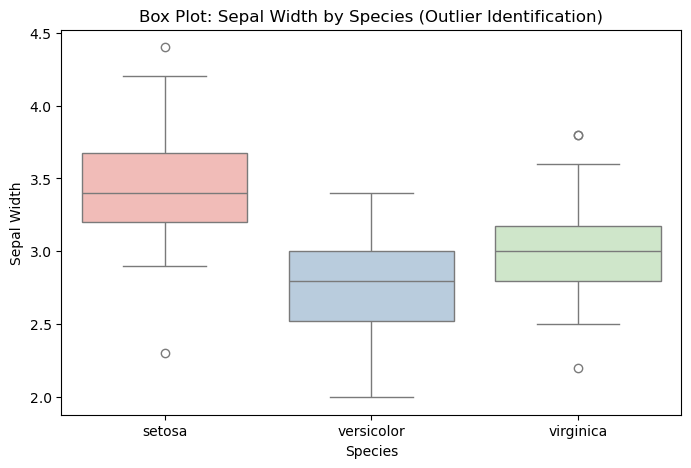

In [26]:
# 1. Scatter Plot (Relationship between Sepal Length and Sepal Width)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='species', palette='Set1')
plt.title('Scatter Plot: Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

# 2. Histogram (Distribution of Petal Length)
plt.figure(figsize=(8, 5))
sns.histplot(data=iris_df, x='petal_length', hue='species', kde=True, bins=20, multiple='stack')
plt.title('Histogram: Distribution of Petal Length')
plt.xlabel('Petal Length')
plt.ylabel('Count')
plt.show()

# 3. Box Plot (Identifying Outliers in Sepal Width)
plt.figure(figsize=(8, 5))
sns.boxplot(data=iris_df, x='species', y='sepal_width', palette='Pastel1')
plt.title('Box Plot: Sepal Width by Species (Outlier Identification)')
plt.xlabel('Species')
plt.ylabel('Sepal Width')
plt.show()

In [27]:
#Task 2: Predict Future Stock Prices (Short-Term)

In [28]:
#Step 1: Install yfinance and Import Libraries
!pip install yfinance

In [29]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Fetch historical stock data for Apple (AAPL)
ticker = 'AAPL'
stock_data = yf.download(ticker, start='2023-01-01', end='2026-06-01')

# Preview the data
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
2023-01-04  124.251190  126.512809  122.992553  124.772344   89113600
2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
2023-01-06  127.456757  128.115573  122.805700  123.907011   87754700
2023-01-09  127.977928  131.183532  127.722273  128.292595   70790800


In [30]:
#Step 2: Feature Engineering & Preprocessing

In [31]:
# Shift the Close price by -1 to create a "Next Day Close" target column
stock_data['Next_Close'] = stock_data['Close'].shift(-1)

# Drop the last row because it won't have a next day's closing price
stock_data = stock_data.dropna()

# Select Features (X) and Target (y)
X = stock_data[['Open', 'High', 'Low', 'Volume', 'Close']]
y = stock_data['Next_Close']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [32]:
#Step 3: Model Training and Evaluation

In [33]:
# Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

Mean Absolute Error (MAE): 2.61
R-squared Score (R2): 0.94


In [34]:
#Step 4: Visualization

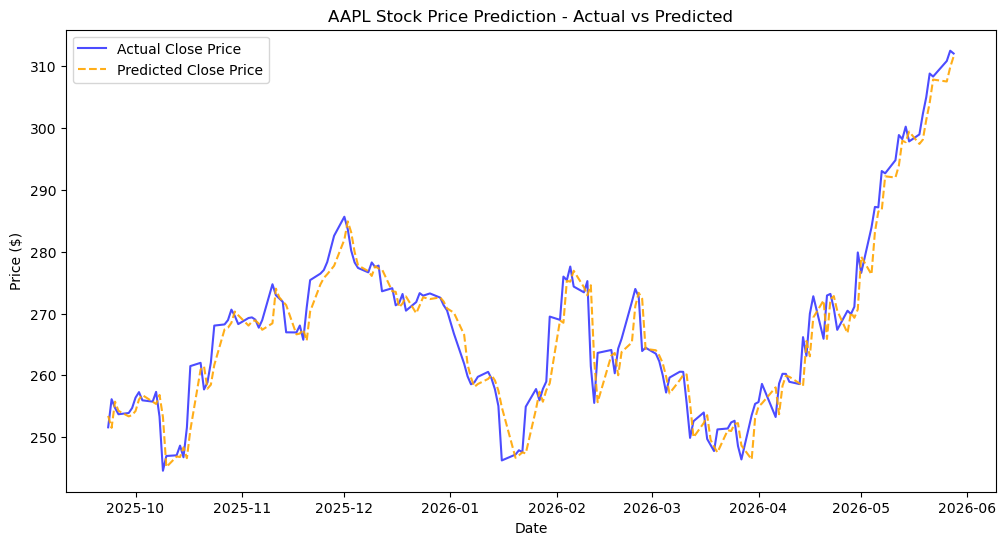

In [35]:
# Plot Actual vs Predicted prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Close Price', color='orange', linestyle='--', alpha=0.9)
plt.title(f'{ticker} Stock Price Prediction - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [36]:
#Task 6: House Price Prediction

In [37]:
#Step 1: Create Dataset & Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Creating a synthetic House Price dataset for demonstration
np.random.seed(42)
n_samples = 200

data = {
    'Square_Feet': np.random.randint(1000, 5000, n_samples),
    'Bedrooms': np.random.randint(1, 6, n_samples),
    'Bathrooms': np.random.randint(1, 4, n_samples),
    'Age_of_House': np.random.randint(0, 30, n_samples)
}

df = pd.DataFrame(data)
# Price formula with added randomness
df['Price'] = (df['Square_Feet'] * 150) + (df['Bedrooms'] * 10000) + (df['Bathrooms'] * 15000) - (df['Age_of_House'] * 2000) + np.random.normal(0, 15000, n_samples)

print(df.head())

   Square_Feet  Bedrooms  Bathrooms  Age_of_House          Price
0         4174         1          1            29  573296.501895
1         4507         4          1            19  720521.881488
2         1860         5          3            15  361691.601811
3         2294         4          2            24  359062.365218
4         2130         5          3            21  346802.982064


In [39]:
#Step 2: Data Preprocessing and Splitting

In [40]:
# Separate Features and Target Variable
X = df[['Square_Feet', 'Bedrooms', 'Bathrooms', 'Age_of_House']]
y = df['Price']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
#Step 3: Train Model and Evaluate
# Initialize and Train Linear Regression
house_model = LinearRegression()
house_model.fit(X_train, y_train)

# Predictions
predictions = house_model.predict(X_test)

# Evaluation using MAE and RMSE
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Mean Absolute Error (MAE): $12772.51
Root Mean Squared Error (RMSE): $15292.97


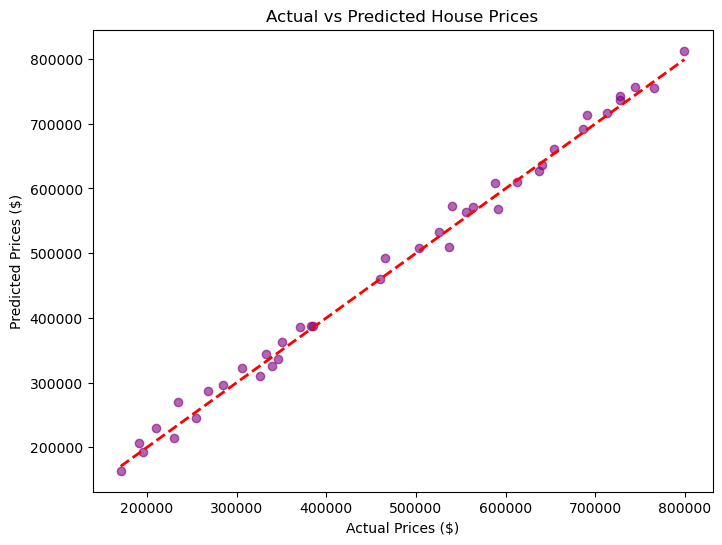

In [42]:
#Step 4: Visualization
# Plotting Actual Prices vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.show()